<a href="https://colab.research.google.com/github/BalamuruganR2004/Data-Science-Project/blob/main/MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ToyotaCorolla - MLR.csv to ToyotaCorolla - MLR.csv


In [6]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
display(df.head())

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [7]:
print("Summary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Summary Statistics:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000



Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Duplicate Rows: 1


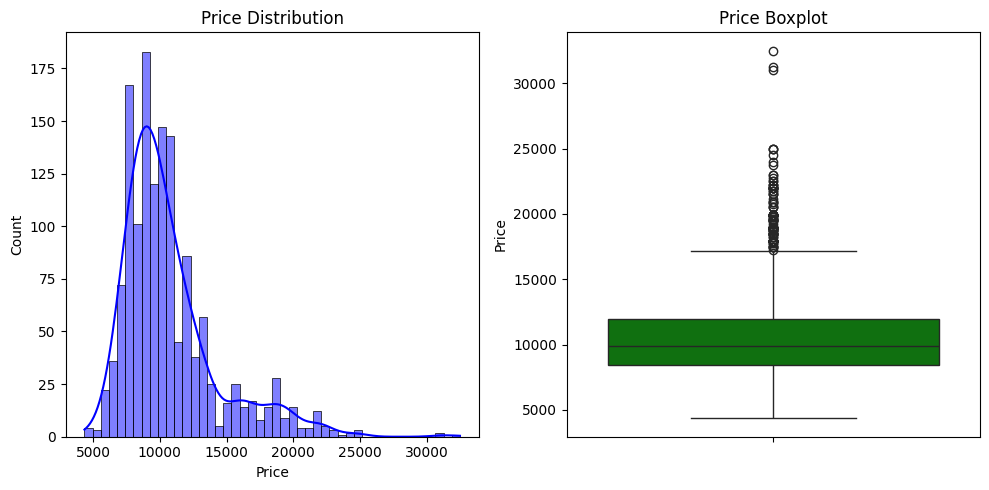

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Price Distribution')

plt.subplot(1,2,2)
sns.boxplot(y=df['Price'], color='green')
plt.title('Price Boxplot')
plt.tight_layout()
plt.show()

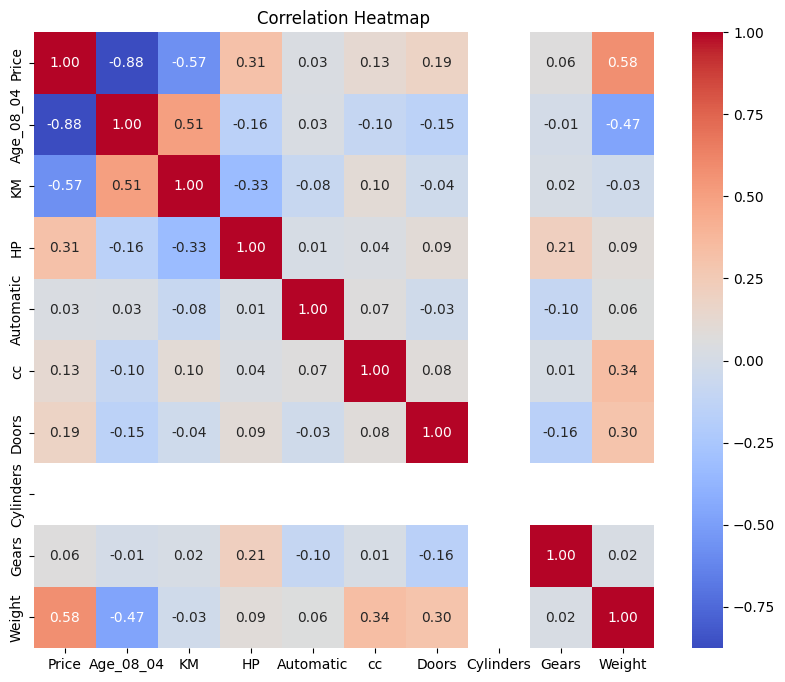

In [9]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

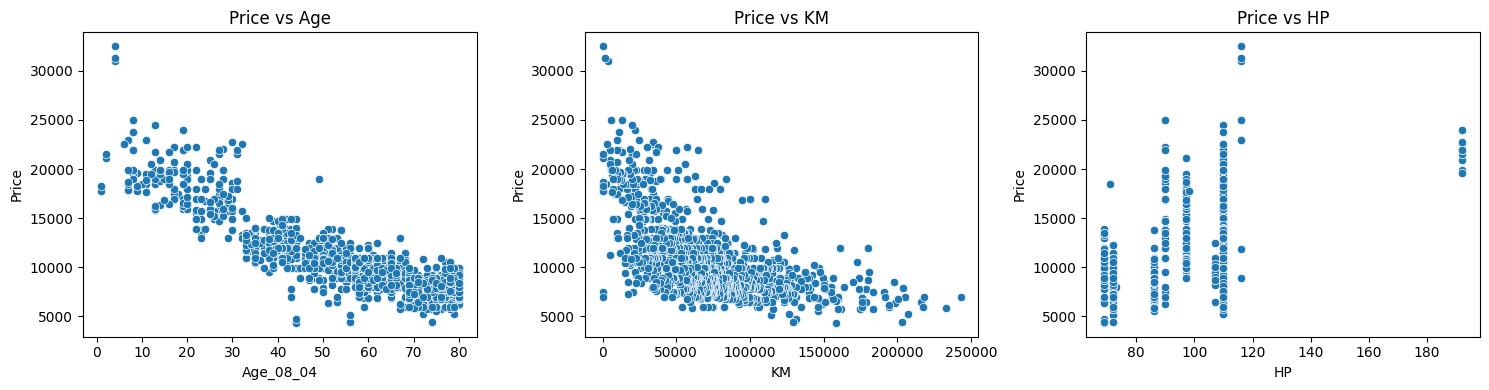

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.scatterplot(x='Age_08_04', y='Price', data=df, ax=axes[0])
axes[0].set_title('Price vs Age')

sns.scatterplot(x='KM', y='Price', data=df, ax=axes[1])
axes[1].set_title('Price vs KM')

sns.scatterplot(x='HP', y='Price', data=df, ax=axes[2])
axes[2].set_title('Price vs HP')

plt.tight_layout()
plt.show()

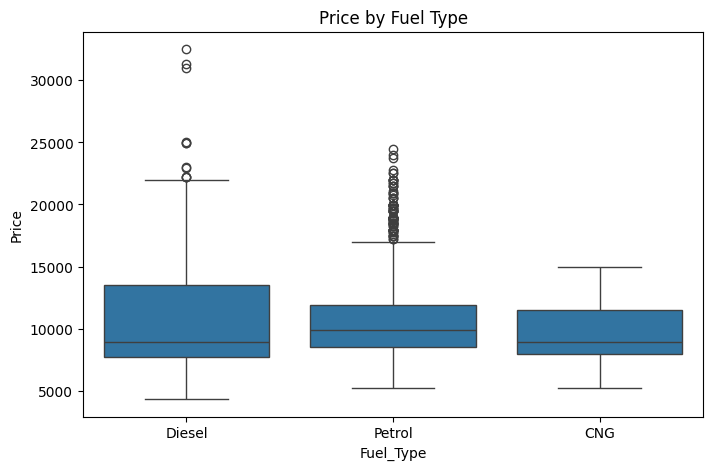

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fuel_Type', y='Price', data=df)
plt.title('Price by Fuel Type')
plt.show()

In [12]:
df_encoded = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

print("After Encoding:")
display(df_encoded.head())

After Encoding:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [13]:
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1436, 11)
Target shape: (1436,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1148
Testing set size: 288


In [15]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("=" * 50)
print("MODEL 1: All Features")
print("=" * 50)
print("\nCoefficients:")
for feature, coef in zip(X.columns, model1.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model1.intercept_:.4f}")

MODEL 1: All Features

Coefficients:
  Age_08_04: -120.8305
  KM: -0.0162
  HP: 14.0395
  Automatic: 148.8309
  cc: -0.0304
  Doors: -60.3110
  Cylinders: -0.0000
  Gears: 551.6007
  Weight: 25.8850
  Fuel_Type_Diesel: -68.5488
  Fuel_Type_Petrol: 1370.8089

Intercept: -14255.3860


In [16]:
correlation = numeric_df.corr()['Price'].abs().sort_values(ascending=False)
top_features = correlation[1:6].index.tolist()
print(f"Top 5 Features: {top_features}")

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

model2 = LinearRegression()
model2.fit(X_train_top, y_train)

print("\n" + "=" * 50)
print("MODEL 2: Top 5 Features Only")
print("=" * 50)
print("\nCoefficients:")
for feature, coef in zip(top_features, model2.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model2.intercept_:.4f}")

Top 5 Features: ['Age_08_04', 'Weight', 'KM', 'HP', 'Doors']

MODEL 2: Top 5 Features Only

Coefficients:
  Age_08_04: -120.0104
  Weight: 19.8804
  KM: -0.0202
  HP: 29.1233
  Doors: -21.0322

Intercept: -5346.9244


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)

print("\n" + "=" * 50)
print("MODEL 3: Standardized Features")
print("=" * 50)
print("\nCoefficients (Standardized):")
for feature, coef in zip(X.columns, model3.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model3.intercept_:.4f}")


MODEL 3: Standardized Features

Coefficients (Standardized):
  Age_08_04: -2267.2948
  KM: -611.6544
  HP: 208.3499
  Automatic: 34.3971
  cc: -14.1619
  Doors: -57.4678
  Cylinders: 0.0000
  Gears: 109.3404
  Weight: 1316.8183
  Fuel_Type_Diesel: -21.7222
  Fuel_Type_Petrol: 458.0477

Intercept: 10754.3955


In [18]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Evaluation:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")

    return r2, rmse

print("=" * 60)
print("MODEL EVALUATION ON TEST DATA")
print("=" * 60)

r2_1, rmse_1 = evaluate_model(model1, X_test, y_test, "Model 1 (All Features)")
r2_2, rmse_2 = evaluate_model(model2, X_test_top, y_test, "Model 2 (Top 5 Features)")
r2_3, rmse_3 = evaluate_model(model3, X_test_scaled, y_test, "Model 3 (Standardized)")

MODEL EVALUATION ON TEST DATA

Model 1 (All Features) Evaluation:
  R² Score: 0.8349
  MSE: 2203043.8231
  RMSE: 1484.2654
  MAE: 990.8873

Model 2 (Top 5 Features) Evaluation:
  R² Score: 0.8508
  MSE: 1990697.7823
  RMSE: 1410.9209
  MAE: 998.9281

Model 3 (Standardized) Evaluation:
  R² Score: 0.8349
  MSE: 2203043.8231
  RMSE: 1484.2654
  MAE: 990.8873


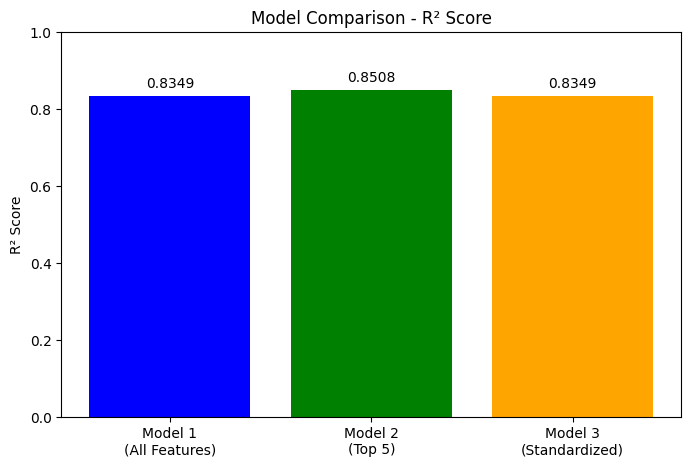

In [19]:
models = ['Model 1\n(All Features)', 'Model 2\n(Top 5)', 'Model 3\n(Standardized)']
r2_scores = [r2_1, r2_2, r2_3]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores, color=['blue', 'green', 'orange'])
plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

In [20]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("=" * 50)
print("RIDGE REGRESSION (L2 Regularization)")
print("=" * 50)
print(f"R² Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

print("\nRidge Coefficients:")
for feature, coef in zip(X.columns, ridge_model.coef_):
    print(f"  {feature}: {coef:.4f}")

RIDGE REGRESSION (L2 Regularization)
R² Score: 0.8350
RMSE: 1483.5575

Ridge Coefficients:
  Age_08_04: -2265.0013
  KM: -613.3595
  HP: 209.5116
  Automatic: 34.5627
  cc: -14.0172
  Doors: -56.6392
  Cylinders: 0.0000
  Gears: 109.4410
  Weight: 1314.4755
  Fuel_Type_Diesel: -22.6329
  Fuel_Type_Petrol: 453.9267


In [21]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("\n" + "=" * 50)
print("LASSO REGRESSION (L1 Regularization)")
print("=" * 50)
print(f"R² Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

print("\nLasso Coefficients:")
for feature, coef in zip(X.columns, lasso_model.coef_):
    print(f"  {feature}: {coef:.4f}")


LASSO REGRESSION (L1 Regularization)
R² Score: 0.8351
RMSE: 1483.2357

Lasso Coefficients:
  Age_08_04: -2267.0589
  KM: -612.2191
  HP: 209.4704
  Automatic: 33.7880
  cc: -12.9854
  Doors: -55.6637
  Cylinders: 0.0000
  Gears: 108.6182
  Weight: 1312.6569
  Fuel_Type_Diesel: -19.3440
  Fuel_Type_Petrol: 456.4547


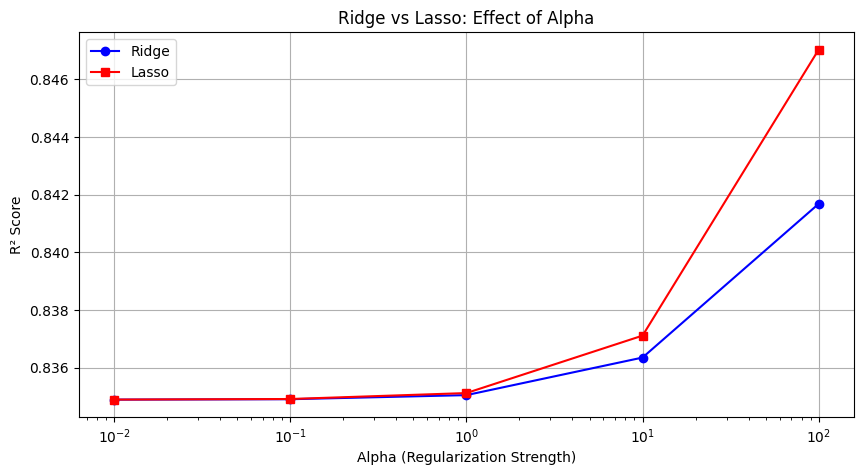

In [22]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_scores.append(r2_score(y_test, ridge.predict(X_test_scaled)))

    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))

plt.figure(figsize=(10,5))
plt.plot(alphas, ridge_scores, 'o-', label='Ridge', color='blue')
plt.plot(alphas, lasso_scores, 's-', label='Lasso', color='red')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Ridge vs Lasso: Effect of Alpha')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print("=" * 60)
print("INTERVIEW QUESTIONS - ANSWERS")
print("=" * 60)

print("""
Q1: What is Normalization & Standardization and how is it helpful?

NORMALIZATION (Min-Max Scaling):
- Formula: X_norm = (X - X_min) / (X_max - X_min)
- Range: 0 to 1
- Use: Neural networks, image processing

STANDARDIZATION (Z-Score):
- Formula: X_std = (X - mean) / std
- Result: Mean = 0, Std = 1
- Use: Linear regression, SVM, PCA

Benefits:
1. Different scale ulla features ah equal weightage kudukkum
2. Gradient descent faster converge aagum
3. Model accuracy improve aagum

----------------------------------------------

Q2: Techniques to address Multicollinearity:

1. VIF (Variance Inflation Factor) - VIF > 10 na remove pannu
2. Remove correlated features - correlation > 0.8 na one remove pannu
3. PCA (Principal Component Analysis) - dimensionality reduction
4. Ridge Regression - L2 penalty multicollinearity handle pannum
5. Combine correlated features - average or ratio edukkalam
""")

INTERVIEW QUESTIONS - ANSWERS

Q1: What is Normalization & Standardization and how is it helpful?

NORMALIZATION (Min-Max Scaling):
- Formula: X_norm = (X - X_min) / (X_max - X_min)
- Range: 0 to 1
- Use: Neural networks, image processing

STANDARDIZATION (Z-Score):
- Formula: X_std = (X - mean) / std
- Result: Mean = 0, Std = 1
- Use: Linear regression, SVM, PCA

Benefits:
1. Different scale ulla features ah equal weightage kudukkum
2. Gradient descent faster converge aagum
3. Model accuracy improve aagum

----------------------------------------------

Q2: Techniques to address Multicollinearity:

1. VIF (Variance Inflation Factor) - VIF > 10 na remove pannu
2. Remove correlated features - correlation > 0.8 na one remove pannu
3. PCA (Principal Component Analysis) - dimensionality reduction
4. Ridge Regression - L2 penalty multicollinearity handle pannum
5. Combine correlated features - average or ratio edukkalam



In [24]:
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

results = pd.DataFrame({
    'Model': ['Linear Regression (All)', 'Linear Regression (Top 5)',
              'Linear Regression (Scaled)', 'Ridge Regression', 'Lasso Regression'],
    'R² Score': [r2_1, r2_2, r2_3,
                 r2_score(y_test, y_pred_ridge),
                 r2_score(y_test, y_pred_lasso)]
})
display(results.sort_values('R² Score', ascending=False))


FINAL MODEL COMPARISON


,Model,R² Score
1,Linear Regression (Top 5),0.850803
4,Lasso Regression,0.835118
3,Ridge Regression,0.835046
0,Linear Regression (All),0.834889
2,Linear Regression (Scaled),0.834889
